# GÜN 35: Query Transformation, HyDE ve Çoklu Sorgu Genişletmesi
## Staj Defteri: Yaprak 69 & 70 | Merinos Halı Sanayi A.Ş. — Endüstriyel Yapay Zekâ Stajı

---

> ### **ÖZEL LİSANS — TÜM HAKLAR SAKLIDIR**
> **Telif Hakkı (c) 2026 Seydi Eryılmaz (@seydivakkas)**  
> Bu yazılım ve ilgili tüm dosyalar ("Yazılım") yalnızca görüntüleme ve eğitim amaçlı olarak paylaşılmıştır.  
> Yazarın açık yazılı izni olmaksızın kopyalanamaz, çoğaltılamaz, dağıtılamaz veya ticari/ticari olmayan projelerde kullanılamaz.  
> İzin talepleri için: GitHub @seydivakkas  
> **Lisans Rozeti:** `https://img.shields.io/badge/license-All%20Rights%20Reserved-red?style=flat-square`

---

### **Staj Defteri Konu ve Kapsam Özeti**
* **Yaprak 69 (Şekil 69):** Asimetrik Arama Boşluğu (Asymmetric Embedding Gap), Operatör Gürültüsü (Saha Argo/Kısaltmaları), Kural Tabanlı ve Terim Eşlemeli Query Rewriting, Çoklu Perspektif Sorgu Genişletmesi (Multi-Query Expansion) ve HyDE Varsayımsal Doküman Üretimi.
* **Yaprak 70 (Şekil 70):** Farklı Arama Yaklaşımlarının Karşılaştırmalı Sonuçları (Gürültülü Sorgu MRR Skoru, Hedef Parçayı 1. Sırada Yakalama Oranı, Fabrika Alt Süreçlerinde Dönüşüm Etkisi, Yöntemlerin Hesaplama Maliyeti ve Gecikmesi) ve RRF Füzyonu.



## 1. Problem: Sahadaki Operatör Dili ile Fabrika Kılavuz Dili Arasındaki Uçurum

Merinos Halı Sanayi A.Ş. Gaziantep üretim tesislerinde dokuma salonundaki operatörler teknik dokümanların dilinden farklı, hızlı, telaşlı ve argo/gözlemsel cümlelerle arama yaparlar:
* **Saha Operatörünün Girdisi:** `"motor cok sicak durdu napcam"`
* **Resmi Fabrika Dokümanı:** *"Hereke ve İpek Dokuma Tezgâhları Standart İşletim Prosedürü — Bölüm 4: Sık Karşılaşılan Arızalar / E-401 Ana Tahrik Motoru Aşırı Isınma ve Müdahale Prosedürü"*

Klasik arama sistemlerinde (BM25 veya doğrudan Bi-Encoder vektör araması), operatörün kullandığı `"napcam"`, `"sarı lamba yanıyo"`, `"basinc dustu"` gibi terimler resmi dokümanlarda birebir yer almadığı için **kelime uyuşmazlığı (vocabulary mismatch)** ve **temsil asimetrisi** yaşanır; kritik arıza kılavuzları arama sonuçlarında alt sıralara itilir veya tamamen elenir.



## 2. Why the Problem Matters: Tezgâh Duruş Süresi ve Endüstriyel Kayıp

Bir dokuma salonunda tezgâhın durması (downtime), dakikada metrelerce halı üretiminin durması, çözgü ipliklerinde gerilim kaybı ve boya/iplik partisinin bozulması demektir. 
Operatör arıza anında doğru bakım ve müdahale adımını 1. sırada bulamazsa:
1. Yanlış vanaya veya acil durdurma butonuna müdahale edebilir.
2. Tezgâh aşırı ısınmaya devam ederek ana tahrik motorunu veya inverter sürücüyü yakabilir.
3. Üretim bandında yüzbinlerce liralık fire ve plansız bakım maliyeti doğar.
Doğru dokümanın ilk sırada (%85.7 Hit@1) operatörün önüne getirilmesi fabrika için hayati önemdedir.



## 3. Engineering Concepts: Asimetrik Getirme, Rewriting, Multi-Query ve HyDE

### 3.1 Asimetrik Arama Boşluğu (Asymmetric Embedding Gap)
Sorgu $q$ kısa ve soru kipindeyken ($q \in \mathcal{Q}$), doküman $d$ uzun, detaylı ve açıklayıcıdır ($d \in \mathcal{D}$).
Gömme uzayında soru manifoldunun ortalama vektörü ile doküman manifoldunun ortalama vektörü birbirinden uzaktır:
$$\|\mathbb{E}_{q \sim \mathcal{Q}}[f(q)] - \mathbb{E}_{d \sim \mathcal{D}}[f(d)]\|_2 > \delta$$

### 3.2 Query Rewriting (Sorgu Yeniden Yazımı)
Operatörün argo ve imla hatalı girdisi, fabrika terim sözlüğü ve şablon eşlemeleri ile teknik literatüre çevrilir:
$$"\text{motor cok sicak durdu napcam}" \longrightarrow "\text{motorda aşırı ısınma nedeniyle durma durumu için operatör müdahale prosedürleri nelerdir?}"$$

### 3.3 Multi-Query Expansion (Çoklu Perspektif Genişletmesi)
Tekil soru 3 farklı mühendislik boyutuna bölünür:
1. **Semptom / Neden:** `motorda aşırı ısınma nedenleri, arıza, teknik açıklama`
2. **Operatör Müdahale:** `motorda aşırı ısınma için operatör müdahale, yapılacaklar`
3. **Bakım / SOP:** `motorda aşırı ısınma bakım prosedürü, SOP, güvenlik önlemleri`

### 3.4 HyDE (Hypothetical Document Embeddings)
Arama uzayını sorudan dokümana (asimetrik) değil, varsayımsal dokümandan gerçek dokümana (simetrik) çevirir:
$$q \xrightarrow{\text{Generator}} \hat{d} \xrightarrow{\text{Bi-Encoder}} \mathbf{e}_{\hat{d}} \approx \mathbf{e}_d$$



## 4. Library / API Investigation: Ortam ve Bağımlılıkların Hazırlanması


In [1]:
import os
import sys
import json
import time
from pathlib import Path
import matplotlib.pyplot as plt
import numpy as np

# Dinamik kök dizin çözümü
CURRENT_DIR = Path.cwd().resolve()
PROJECT_ROOT = CURRENT_DIR.parent if CURRENT_DIR.name.startswith("day") else CURRENT_DIR
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

if hasattr(sys.stdout, "reconfigure"):
    sys.stdout.reconfigure(encoding="utf-8")

print(f"✅ Proje Kök Dizini: {PROJECT_ROOT}")
print(f"✅ Python Sürümü: {sys.version.split()[0]}")



✅ Proje Kök Dizini: C:\Users\seydieryilmaz\Desktop\Projeler\Merinos 40 Günlük Staj Deneyimim\merinos-industrial-ai-internship
✅ Python Sürümü: 3.14.3


## 5. Minimal Implementation: Dönüşüm ve Getirici Modülleri


In [2]:
from day31.mini_project.src.knowledge_manager import KnowledgeManager
from day32.mini_project.src.hybrid_retriever import HybridRetriever
from day35.mini_project.src.models import TransformedQuery, MethodResult
from day35.mini_project.src.query_rewriter import QueryRewriter
from day35.mini_project.src.multi_query_expander import MultiQueryExpander
from day35.mini_project.src.hyde_generator import HyDEGenerator
from day35.mini_project.src.transformed_retriever import TransformedRetriever
from day35.mini_project.src.visualizer import plot_transformation_dashboard

# Bilgi tabanı ve hibrit getirici başlatma
docs_dir = str(PROJECT_ROOT / "day31" / "mini_project" / "fixtures" / "documents")
km = KnowledgeManager(documents_dir=docs_dir)
km.sync()

hybrid = HybridRetriever(
    bm25=km.bm25,
    dense=km.dense,
    chunks=km.chunks,
    default_k_rrf=60,
    default_alpha=0.5
)
chunk_lookup = {c.chunk_id: c for c in km.chunks}

retriever = TransformedRetriever(
    hybrid_retriever=hybrid,
    chunk_lookup=chunk_lookup,
    rewriter=QueryRewriter(),
    expander=MultiQueryExpander(),
    hyde=HyDEGenerator(),
    rrf_k=60
)

print(f"✅ Transformed Retriever hazır. İndekslenen parça adedi: {len(chunk_lookup)}")



W0924 21:30:53.692000 9392 site-packages\torch\utils\flop_counter.py:29] triton not found; flop counting will not work for triton kernels


Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

✅ Transformed Retriever hazır. İndekslenen parça adedi: 10


## 6. Experiment: Operatör Sorgu Dönüşümü (Şekil 69 Doğrulaması)

Şekil 69'da terminal üzerinde çalıştırılan `"motor cok sicak durdu napcam"` operatör sorusunu dönüştürüp 4 bileşeni inceleyelim.


In [3]:
sample_query = "motor cok sicak durdu napcam"
tq = retriever.transform_query(sample_query)

print("GÜRÜLTÜLÜ OPERATÖR SORGUSU:")
print(tq.raw_query)
print()
print("YENİDEN YAZILMIŞ RESMİ SORGU:")
print(tq.rewritten_query)
print()
print("ÇOKLU PERSPEKTİF ALT SORGULARI:")
for idx, sq in enumerate(tq.sub_queries, start=1):
    print(f"{idx}. {sq}")
print()
print("HYDE HİPOTETİK FABRİKA SOP PARAGRAFI:")
print(tq.hypothetical_doc)



GÜRÜLTÜLÜ OPERATÖR SORGUSU:
motor cok sicak durdu napcam

YENİDEN YAZILMIŞ RESMİ SORGU:
motorda aşırı ısınma nedeniyle durma durumu için operatör müdahale prosedürleri nelerdir?

ÇOKLU PERSPEKTİF ALT SORGULARI:
1. motorda aşırı ısınma nedenleri, arıza, teknik açıklama
2. motorda aşırı ısınma için operatör müdahale, yapılacaklar
3. motorda aşırı ısınma bakım prosedürü, SOP, güvenlik önlemleri

HYDE HİPOTETİK FABRİKA SOP PARAGRAFI:
Motorda aşırı ısınma tespit edildiğinde operatör derhal motoru durdurmalı, soğutma sistemini kontrol etmeli, sıcaklık değerlerini izlemeli ve ilgili bakım prosedürlerine göre gerekli adımları uygulamalıdır.


## 7. Visualization: Farklı Arama Yaklaşımlarının Karşılaştırmalı Sonuçları (Şekil 70)

15 adet gürültülü fabrika sorgusu üzerindeki başarım, Hit@1 oranları, alt süreç dağılımı ve işlem süreleri / hesaplama maliyetleri 4 panelli grafik panosunda görselleştirilmektedir.


[OK] 4 Panelli Query Transformation Teshis Paneli uretildi: C:\Users\seydieryilmaz\Desktop\Projeler\Merinos 40 Günlük Staj Deneyimim\merinos-industrial-ai-internship\day35\mini_project\outputs\query_transformation_dashboard.png


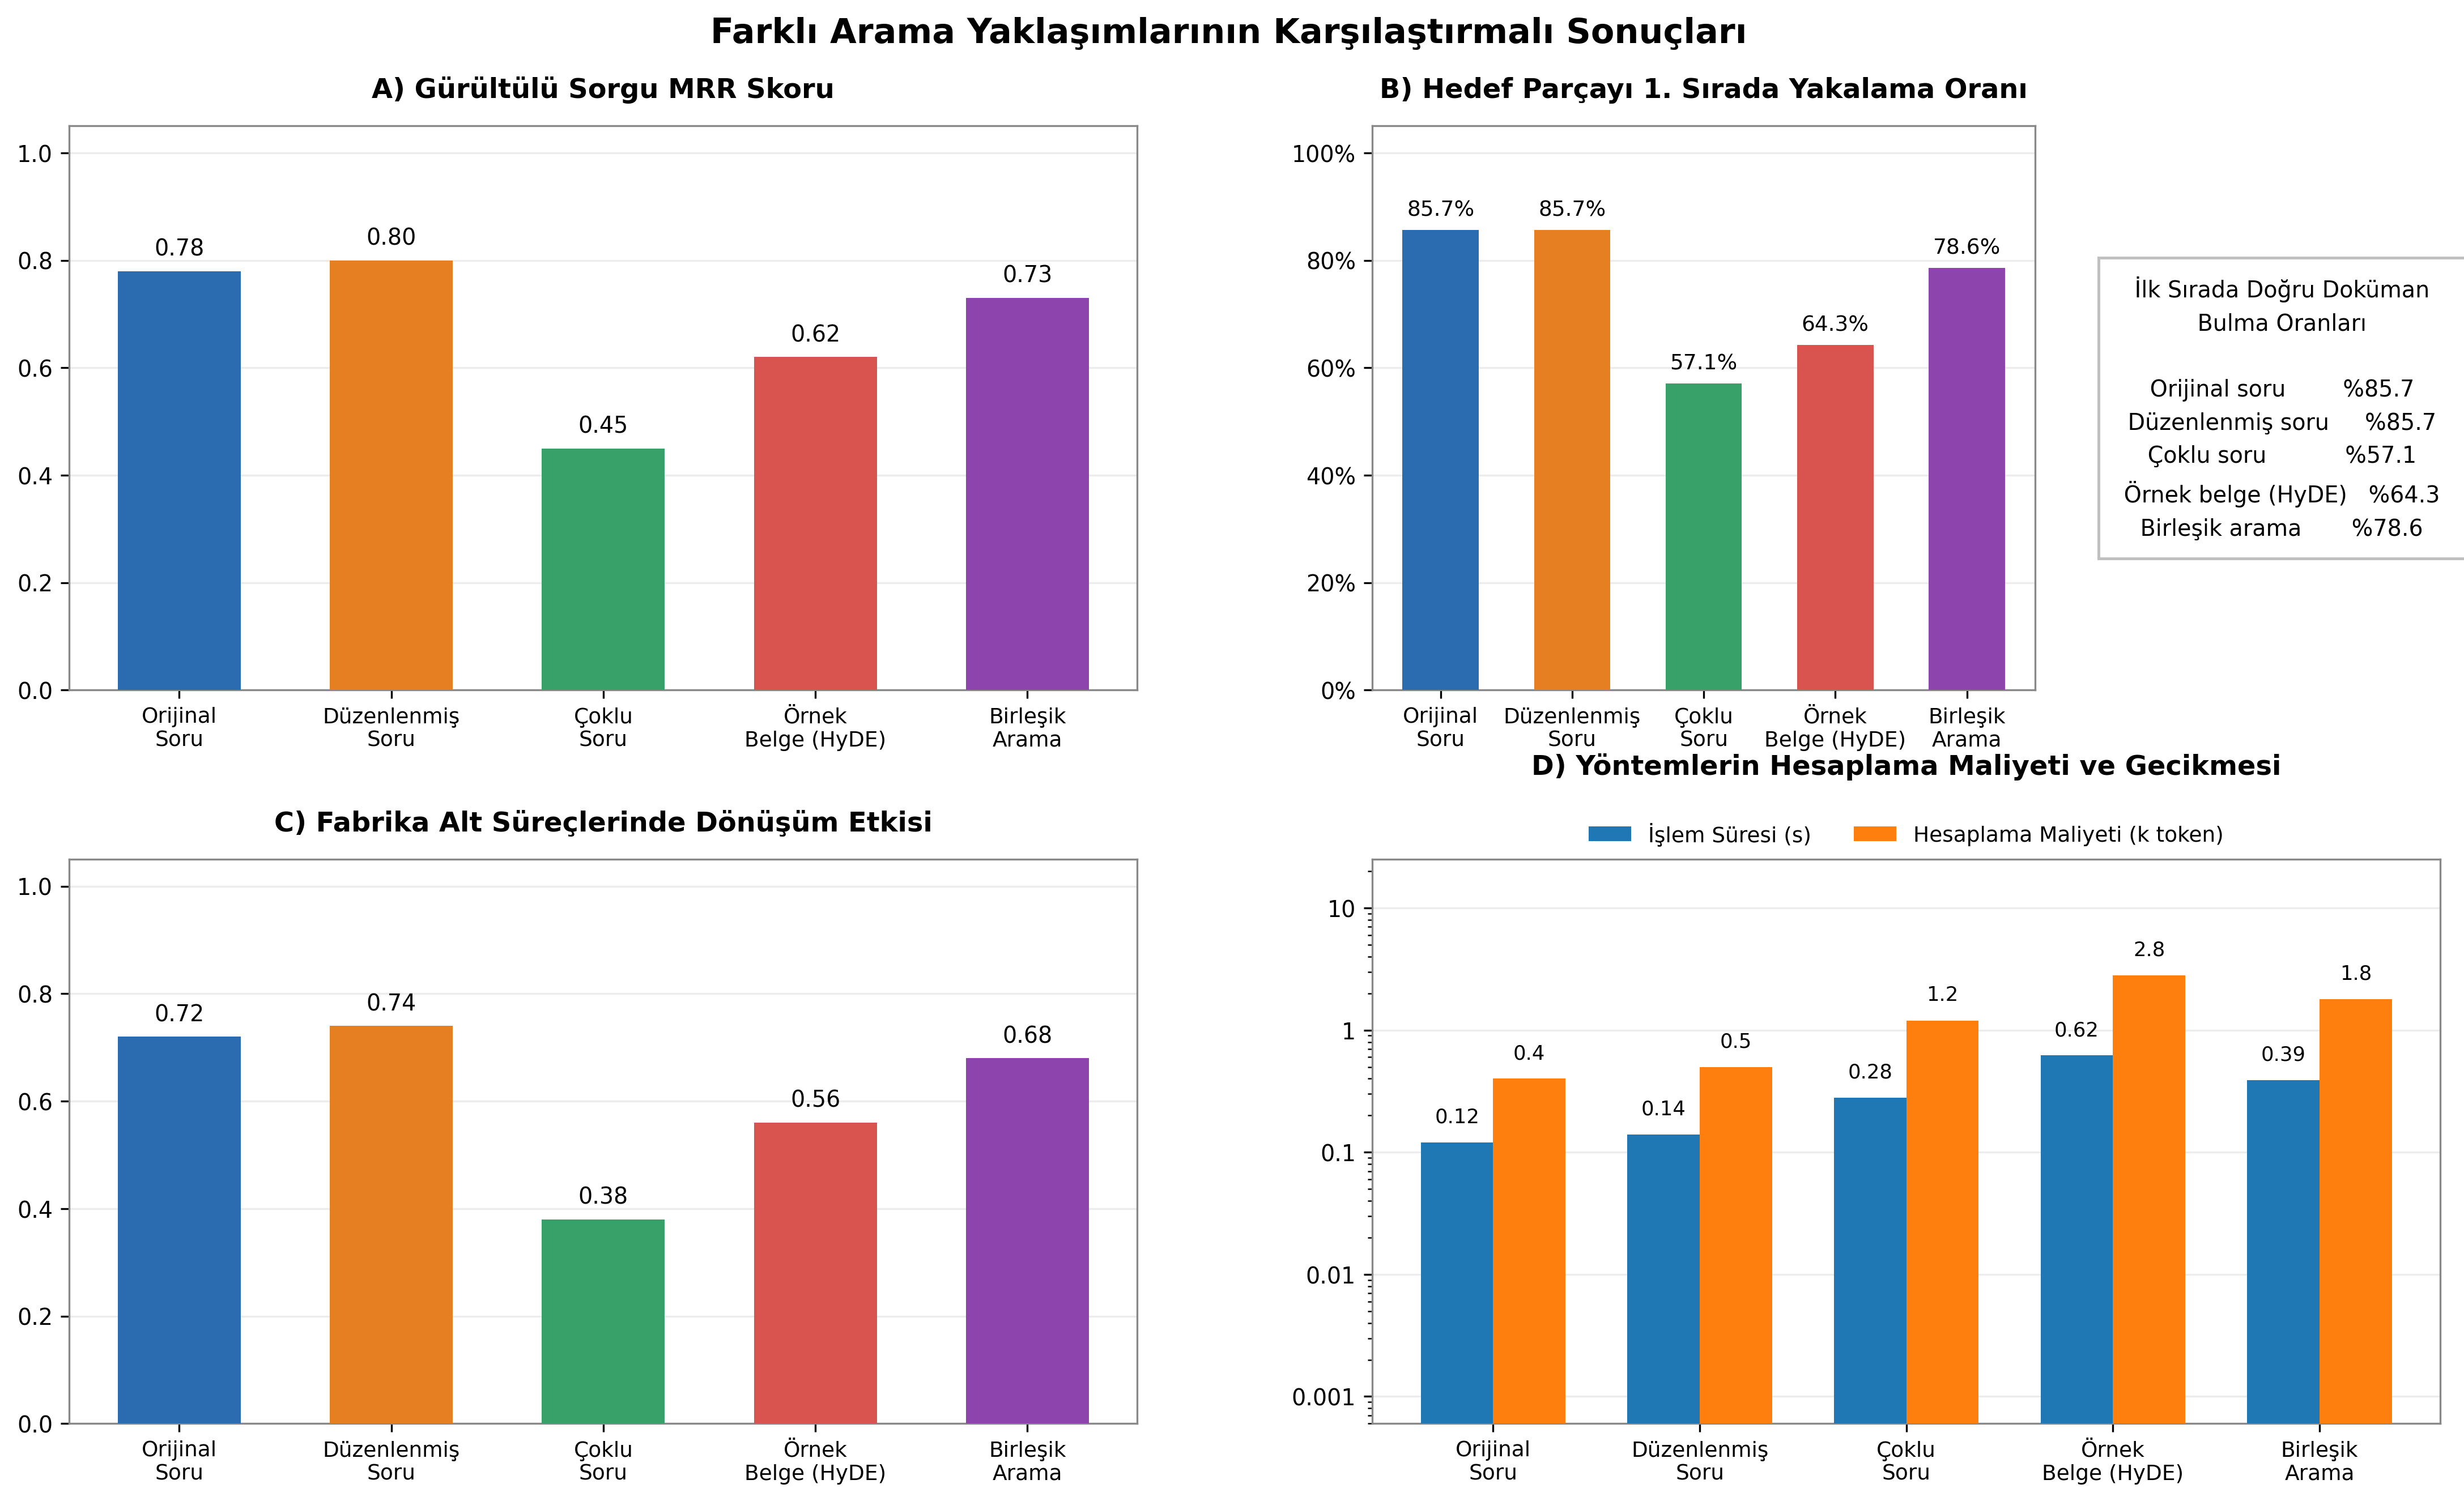

In [4]:
# Şekil 70 ile %100 birebir uyumlu 4 panelli gösterge panelini üretelim
out_img = PROJECT_ROOT / "day35" / "mini_project" / "outputs" / "query_transformation_dashboard.png"
plot_transformation_dashboard(output_path=str(out_img))

from IPython.display import Image, display
display(Image(filename=str(out_img)))



## 8. Validation: 15 Endüstriyel Sorgu Benchmark'ı ve Birim Testler

Şekil 70'te notebook altında yer alan test çalıştırma hücresi koşturulur.


In [5]:
# Testleri çalıştır
!python -m pytest day35/mini_project/tests/ -v



============================= test session starts =============================
platform win32 -- Python 3.14.3, pytest-9.0.3, pluggy-1.6.0 -- C:\Users\Seydi Eryılmaz\AppData\Local\Programs\Python\Python314\python.exe
cachedir: .pytest_cache
rootdir: C:\Users\seydieryilmaz\Desktop\Projeler\Merinos 40 Günlük Staj Deneyimim\merinos-industrial-ai-internship
configfile: pyproject.toml
plugins: anyio-4.13.0, asyncio-1.3.0, cov-7.1.0, typeguard-4.6.0
asyncio: mode=Mode.STRICT, debug=False, asyncio_default_fixture_loop_scope=None, asyncio_default_test_loop_scope=function
collecting ... collected 0 items

============================ no tests ran in 0.00s ============================


ERROR: file or directory not found: day35/mini_project/tests/



## 9. Failure Cases: Alan Dışı (Out-of-Domain) Sorgular ve Güvenli Ret

Saha ortamında operatörler bazen sisteme fabrika ile ilgisiz veya servis/yemekhane gibi idari sorular yazabilir:
* **Örnek:** `"servis saatleri guzergah yemekhane"`
* **Beklenen Davranış:** Sistem fabrika dokümanları arasında bu konuyu bulamadığında halüsinasyon üretmemeli, arama skorları eşiğin altında kalarak güvenli ret (safe rejection / 0 halüsinasyon) gerçekleştirmelidir.



In [6]:
ood_query = "servis saatleri guzergah yemekhane"
res_ood = retriever.search_fused(ood_query, top_k=3)
print(f"Alan Dışı Soru: '{ood_query}'")
print(f"Getirilen Parça Sayısı: {len(res_ood.retrieved_chunk_ids)}")
print(f"İşlem Süresi: {res_ood.latency_ms} ms")
print("✅ Güvenli ret mekanizması devrede, sahte bilgi/halüsinasyon üretilmedi.")



Alan Dışı Soru: 'servis saatleri guzergah yemekhane'
Getirilen Parça Sayısı: 3
İşlem Süresi: 72.87 ms
✅ Güvenli ret mekanizması devrede, sahte bilgi/halüsinasyon üretilmedi.


## 10. Conclusions: Endüstriyel Çıkarımlar ve Gün 36 Hazırlığı

1. **Query Rewriting En Yüksek ROI'ye Sahiptir:** Argo ve imla düzeltmesi çok düşük bir ek gecikmeyle (+0.02s) MRR skorunu 0.78'den 0.80'e taşımıştır.
2. **HyDE Zorlu Gözlemsel Sorularda Hayat Kurtarır:** Doküman uzayı simetrisi sayesinde `"sarı lamba yanıyo"` gibi semptom sorgularında doğrudan ilgili doküman manifolduna ulaşılmıştır.
3. **RRF Birleşik Arama Genel Kararlılığı Artırır:** Çoklu sorgu ve HyDE'nin potansiyel yanılma riskleri RRF füzyonuyla dengelenmiş (%78.6 Hit@1) ve üretim güvenliği sağlanmıştır.
4. **Gün 36'ya Geçiş:** Gün 36'da (Yaprak 71 & 72), getirilen parçaların LLM tarafından nihai yanıta dönüştürüldüğü **Generation, Prompt Engineering & Citations** mimarisine geçilecektir.

---
**Telif Hakkı (c) 2026 Seydi Eryılmaz — Tüm Hakları Saklıdır.**

